In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# Load Data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Reshape and Normalize Data
x_train = x_train.reshape((x_train.shape[0], -1)) / 255.0
x_test = x_test.reshape((x_test.shape[0], -1)) / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Training SVM (Poly kernel, Degree=2, C=10, coef0=1)...
[LibSVM]Elapsed time 521.4 seconds.
Accuracy: 0.5420


<Figure size 1200x1200 with 0 Axes>

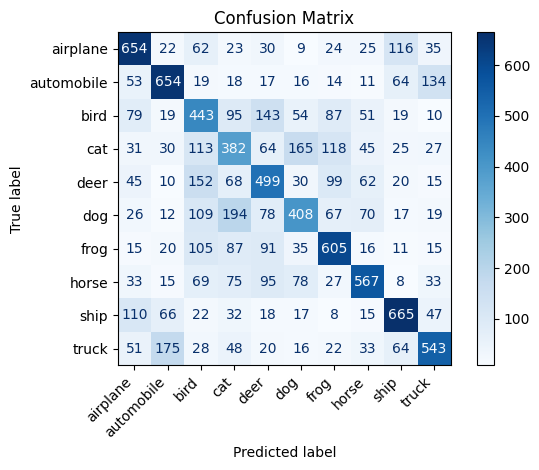

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time


C_value = 10
degree = 2
coef0 = 1


pipe_poly_custom = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),
    ('svm', SVC(
        kernel='poly',
        degree=degree,
        C=C_value,
        coef0=coef0,
        cache_size=1000,
        verbose=True
    ))
])

print(f"Training SVM (Poly kernel, Degree={degree}, C={C_value}, coef0={coef0})...")
start = time.time()


pipe_poly_custom.fit(x_train, y_train)

print(f"Elapsed time {time.time() - start:.1f} seconds.")

acc = pipe_poly_custom.score(x_test, y_test)
print(f"Accuracy: {acc:.4f}")


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12, 12))

disp = ConfusionMatrixDisplay.from_estimator(
    pipe_poly_custom,
    x_test,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize=None,
    values_format='d'
)

plt.xticks(rotation=45, ha='right')
plt.title(f"Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:

svm_model = pipe_poly_custom.named_steps['svm']

#total number of support vectors
total_sv = svm_model.support_.shape[0]

# number of support vectors per class
sv_per_class = svm_model.n_support_

print(f"Total Support Vectors: {total_sv}")
print(f"Support Vectors per class: {sv_per_class}")

# percentage of training set that became support vectors
print(f"Percentage of training set used as SVs: {total_sv / len(x_train) * 100:.2f}%")

Total Support Vectors: 40050
Support Vectors per class: [3638 3489 4585 4634 4545 4364 3982 3646 3347 3820]
Percentage of training set used as SVs: 80.10%


Training SVM with RBF kernel (C=10, gamma=scale)...
[LibSVM]Elapsed time: 595.6 seconds.
Evaluating model...
Accuracy: 0.5713


<Figure size 1200x1200 with 0 Axes>

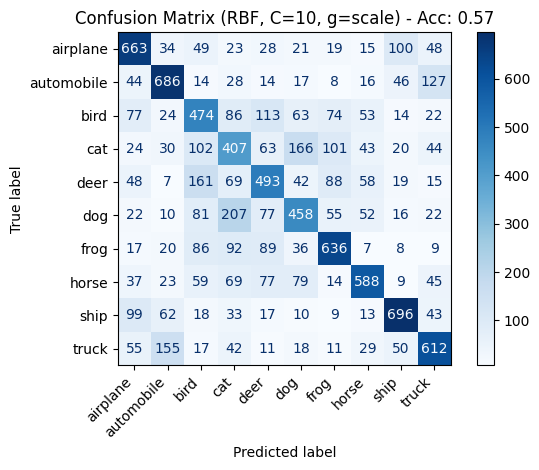

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time


C_value = 10
gamma_value = 'scale'


pipe_rbf_custom = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(
        kernel='rbf',
        C=C_value,
        gamma=gamma_value,
        decision_function_shape='ovr', # One-vs-Rest
        cache_size=1000,               #
        verbose=True
    ))
])

print(f"Training SVM with RBF kernel (C={C_value}, gamma={gamma_value})...")
start = time.time()

# Εκπαίδευση
pipe_rbf_custom.fit(x_train, y_train)

print(f"Elapsed time: {time.time() - start:.1f} seconds.")

# Αξιολόγηση
print("Evaluating model...")
y_pred = pipe_rbf_custom.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12, 12))

disp = ConfusionMatrixDisplay.from_estimator(
    pipe_rbf_custom,
    x_test,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize=None,
    values_format='d'
)

# rotate labels
plt.xticks(rotation=45, ha='right')
plt.title(f"Confusion Matrix (RBF, C={C_value}, g={gamma_value}) - Acc: {accuracy:.2f}")
plt.tight_layout()
plt.show()